In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['rhenusallee'].sum())
header = 'rhenusallee'

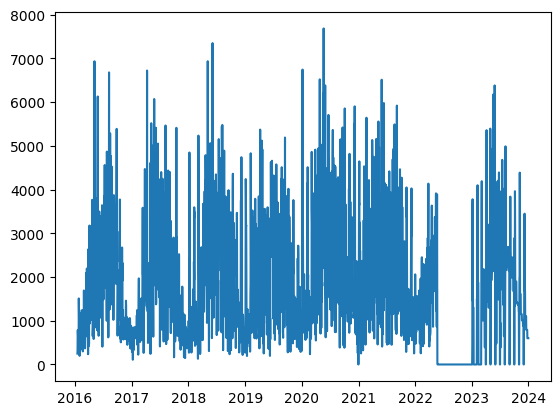

In [2]:
plt.plot(df[header])

In [3]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

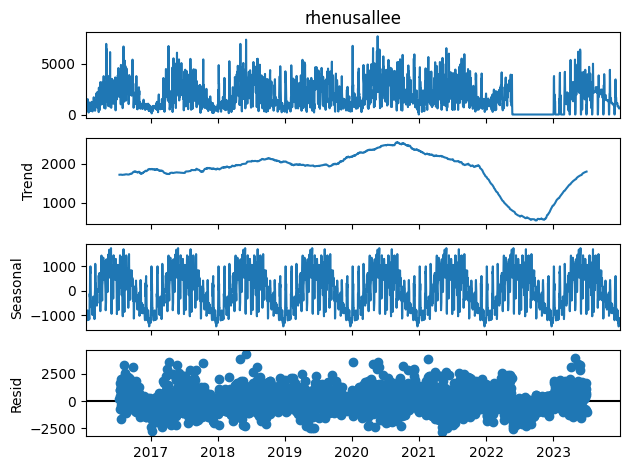

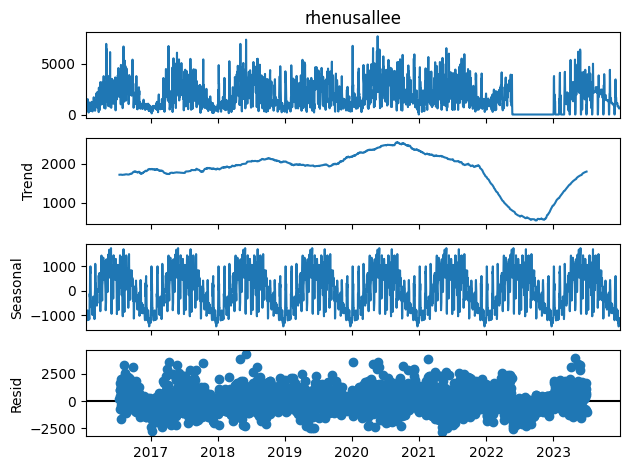

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df[header], period=365)
decomposition.plot()

In [5]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



Seasonal ARIMA

In [7]:
#Mittelwertbereinigung
df['days_noyear'] = pd.to_datetime(df.index).strftime('%m-%d')
df['day_mean'] = df.groupby('days_noyear')['log'].transform('mean')
df['cleaned_by_mean'] = df['log'] - df['day_mean']
display(df)

,rhenusallee,scaled,log,days_noyear,day_mean,cleaned_by_mean
2016-01-16,249,249.967599,5.521331,01-16,5.955300,-0.433969
2016-01-17,316,316.958881,5.758772,01-17,5.626258,0.132514
2016-01-18,783,783.898113,6.664279,01-18,5.963601,0.700678
2016-01-19,770,770.899805,6.647558,01-19,5.903579,0.743979
2016-01-20,668,668.913077,6.505654,01-20,5.884311,0.621343
...,...,...,...,...,...,...
2023-12-27,600,600.921926,6.398465,12-27,5.568262,0.830203
2023-12-28,600,600.921926,6.398465,12-28,5.735836,0.662629
2023-12-29,600,600.921926,6.398465,12-29,5.704865,0.693600
2023-12-30,600,600.921926,6.398465,12-30,5.841080,0.557385


In [8]:
df['weekday'] = df.index.dayofweek  # 0 = Montag, 6 = Sonntag
weekly_pattern = df.groupby('weekday')[header].mean()
print(weekly_pattern)

weekday
0    1763.171084
1    1791.532530
2    1853.937349
3    1794.024096
4    1710.734940
5    1774.651442
6    2093.204327
Name: rhenusallee, dtype: float64


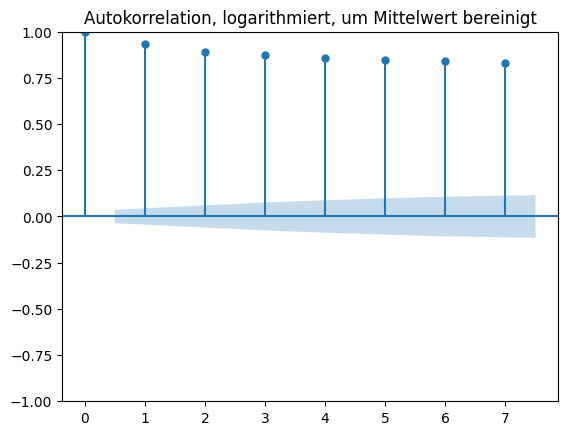

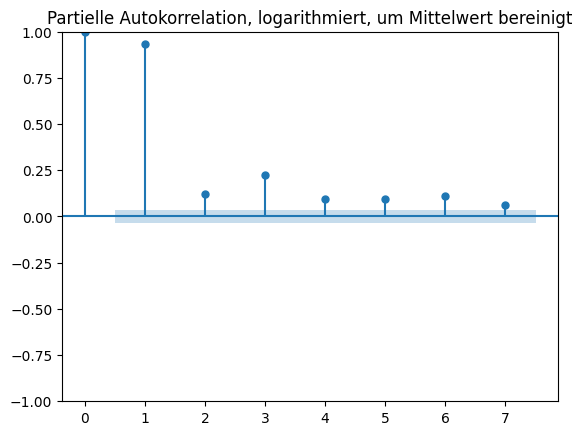

In [9]:
lags  = 7
plot_acf(df['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()
#für Order-Ebene, Lag 1 signifikant

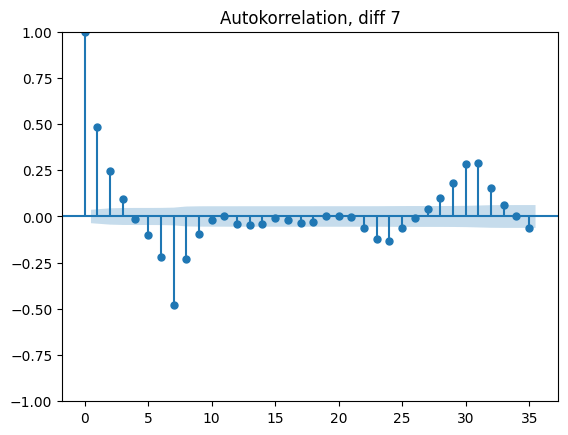

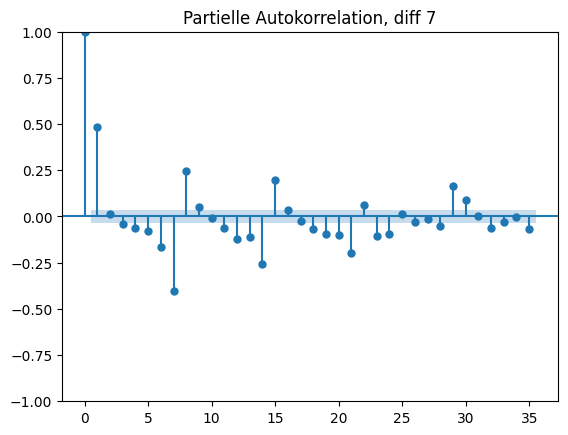

In [10]:
diffs = df[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [11]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df) * 0.8)
df_train_seas = df.iloc[:end_train]
df_test_seas = df.iloc[end_train:]

seasonal = 7
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()
result9 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(1, 1, 0, seasonal)).fit()
result10 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(1, 1, 1, seasonal)).fit()

results = [result1, result2, result3, result4, result5, result6, result7, result8, result9, result10]
print('ARIMA (0,0,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,7) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))
print('ARIMA (0,1,1)x(0,1,1,7) LL {:.4f}, AIC: {:.4f}'.format(result9.llf, result9.aic))
print('ARIMA (0,1,1)x(1,1,1,7) LL {:.4f}, AIC: {:.4f}'.format(result10.llf, result10.aic))


ARIMA (0,0,0)x(0,1,0,7) LL -3121.5790, AIC: 6245.1581
ARIMA (0,1,0)x(0,1,0,7) LL -3027.3959, AIC: 6056.7918
ARIMA (1,0,0)x(0,1,1,7) LL -2115.9632, AIC: 4237.9263
ARIMA (1,0,0)x(0,1,2,7) LL -2111.3610, AIC: 4230.7221
ARIMA (1,1,0)x(0,1,2,7) LL -2207.4385, AIC: 4422.8770
ARIMA (0,0,1)x(0,1,2,7) LL -2309.6903, AIC: 4627.3805
ARIMA (0,1,1)x(0,1,2,7) LL -2158.1771, AIC: 4324.3543
ARIMA (0,1,1)x(2,1,0,7) LL -2402.3393, AIC: 4812.6786
ARIMA (0,1,1)x(0,1,1,7) LL -2577.0647, AIC: 5160.1294
ARIMA (0,1,1)x(1,1,1,7) LL -2158.1771, AIC: 4324.3543


In [26]:
print(result4.summary())

                                       SARIMAX Results                                        
Dep. Variable:                                    log   No. Observations:                 2326
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 7)   Log Likelihood               -2111.361
Date:                                Mon, 10 Feb 2025   AIC                           4230.722
Time:                                        23:08:43   BIC                           4253.718
Sample:                                    01-16-2016   HQIC                          4239.102
                                         - 05-29-2022                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6595      0.006    102.187      0.000       0.647       0.672
ma.

In [27]:
results_final = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
y_pred_no_update = results_final.predict(start='2022-05-30', end='2024-03-30')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)


            predicted_mean     unlogged  new_predict
2022-05-30        2.383146    10.838945     9.840225
2022-05-31        3.777075    43.688054    42.693610
2022-06-01        4.656735   105.291780   104.305352
2022-06-02        5.245801   189.767812   188.792378
2022-06-03        5.764886   318.902713   317.944085
...                    ...          ...          ...
2024-03-26        7.249858  1407.905420  1407.088516
2024-03-27        7.271322  1438.450915  1437.637986
2024-03-28        7.126226  1244.172129  1243.333916
2024-03-29        7.169192  1298.794558  1297.963454
2024-03-30        7.258644  1420.328682  1419.513395

[671 rows x 3 columns]


Text(0.5, 1.0, 'Prognose')

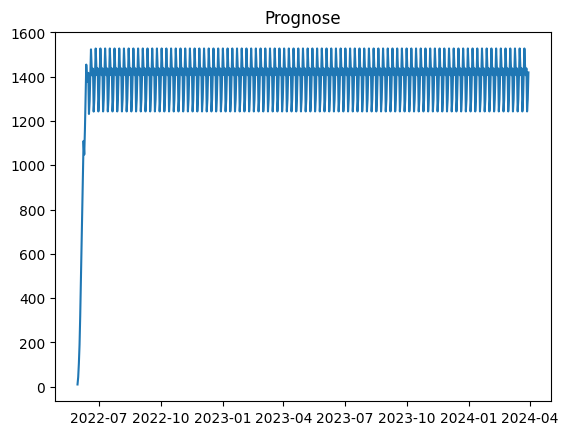

In [28]:
plt.plot(y_pred_no_update['new_predict'])
plt.title('Prognose')

Text(0.5, 1.0, 'tatsächliche Daten')

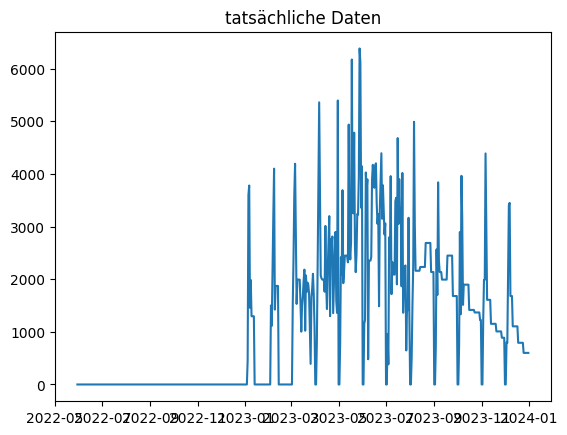

In [29]:
plt.plot(df_test_seas[header])
plt.title('tatsächliche Daten')

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal), freq='D')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal), freq='D')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2022-05-30', end='2024-12-31')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])

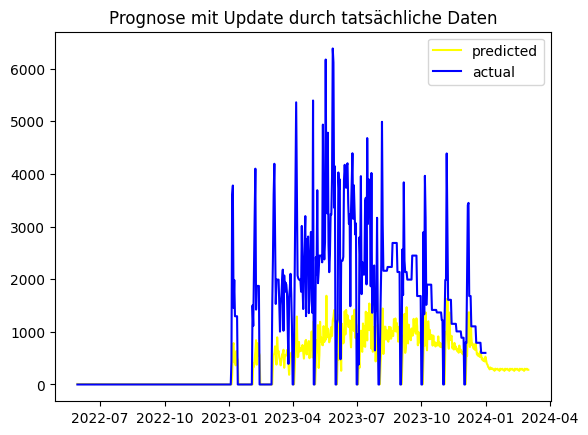

In [31]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2022-05-30'
end_date = '2024-03-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [32]:
mape_bound = 100

df_test_seas.loc[:,'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:,'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mape_arima = sum(mape_arima)/len(mape_arima)


print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 740.7912
mean squared error (mse): ARIMA: 1515204.7090
mean absolute percentage error (mape): ARIMA: 0.6000
